In [2]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
events = pd.read_csv("D:\project\flood\Flood-Prediction-System-ML\data\raw\INDOFLOODS event.csv")

precipitation = pd.read_csv(
    "D:\project\flood\Flood-Prediction-System-ML\data\raw\Precipitation.csv"
)

catchment = pd.read_csv(
    "D:\project\flood\Flood-Prediction-System-ML\data\raw\Catchment.csv"
)

print("Datasets loaded successfully!")

print("\nEvent dataset shape:")
print(events.shape)

print("\nPrecipitation dataset shape:")
print(precipitation.shape)

print("\nCatchment dataset shape:")
print(catchment.shape)

Datasets loaded successfully!

Event dataset shape:
(4548, 13)

Precipitation dataset shape:
(4548, 11)

Catchment dataset shape:
(155, 108)


In [5]:
# ============================================================
# CELL 3: BASIC INSPECTION
# ============================================================

print("EVENT DATA")
print(events.head())

print("\nEVENT COLUMNS")
print(events.columns.tolist())

print("\nPRECIPITATION DATA")
print(precipitation.head())

print("\nCATCHMENT DATA")
print(catchment.head())

EVENT DATA
                   EventID  Start Date    End Date  Peak Flood Level (m)  \
0  INDOFLOODS-gauge-1010-1  2010-07-21  2010-07-21                 47.95   
1  INDOFLOODS-gauge-1010-2  2016-07-23  2016-07-23                 48.05   
2  INDOFLOODS-gauge-1010-3  2016-07-26  2016-07-26                 48.00   
3  INDOFLOODS-gauge-1010-4  2017-08-11  2017-08-13                 48.95   
4  INDOFLOODS-gauge-1012-1  2010-07-21  2010-07-21                 48.10   

  Peak FL Date  Num Peak FL  Peak Discharge Q (cumec) Peak Discharge Date  \
0   2010-07-21            1                       NaN                 NaN   
1   2016-07-23            1                       NaN                 NaN   
2   2016-07-26            1                       NaN                 NaN   
3   2017-08-12            1                       NaN                 NaN   
4   2010-07-21            1                       NaN                 NaN   

   Flood Volume (cumec)  Event Duration (days)  Time to Peak (days)  

In [6]:
# ============================================================
# CELL 4: CHECK FLOOD TYPE
# ============================================================

print("Flood Type distribution:")

print(events["Flood Type"].value_counts())

print("\nFlood Type percentage:")

print(
    events["Flood Type"]
    .value_counts(normalize=True) * 100
)

Flood Type distribution:
Flood Type
Flood           2919
Severe Flood    1629
Name: count, dtype: int64

Flood Type percentage:
Flood Type
Flood           64.182058
Severe Flood    35.817942
Name: proportion, dtype: float64


In [7]:
# ============================================================
# CELL 5: CREATE GAUGE ID
# ============================================================

events["GaugeID"] = (
    events["EventID"]
    .str.rsplit("-", n=1)
    .str[0]
)

print(
    events[
        ["EventID", "GaugeID"]
    ].head(10)
)

                   EventID                GaugeID
0  INDOFLOODS-gauge-1010-1  INDOFLOODS-gauge-1010
1  INDOFLOODS-gauge-1010-2  INDOFLOODS-gauge-1010
2  INDOFLOODS-gauge-1010-3  INDOFLOODS-gauge-1010
3  INDOFLOODS-gauge-1010-4  INDOFLOODS-gauge-1010
4  INDOFLOODS-gauge-1012-1  INDOFLOODS-gauge-1012
5  INDOFLOODS-gauge-1013-1  INDOFLOODS-gauge-1013
6  INDOFLOODS-gauge-1013-2  INDOFLOODS-gauge-1013
7  INDOFLOODS-gauge-1013-3  INDOFLOODS-gauge-1013
8  INDOFLOODS-gauge-1013-4  INDOFLOODS-gauge-1013
9  INDOFLOODS-gauge-1013-5  INDOFLOODS-gauge-1013


In [8]:
# ============================================================
# CELL 6: CHECK JOIN KEYS
# ============================================================

print(
    "Unique Event IDs in event data:",
    events["EventID"].nunique()
)

print(
    "Unique Event IDs in precipitation:",
    precipitation["EventID"].nunique()
)

print(
    "Unique Gauge IDs in catchment:",
    catchment["GaugeID"].nunique()
)

print(
    "\nEvents without a matching precipitation record:"
)

print(
    (~events["EventID"].isin(
        precipitation["EventID"]
    )).sum()
)

print(
    "\nEvents without a matching catchment record:"
)

print(
    (~events["GaugeID"].isin(
        catchment["GaugeID"]
    )).sum()
)

Unique Event IDs in event data: 4548
Unique Event IDs in precipitation: 4548
Unique Gauge IDs in catchment: 155

Events without a matching precipitation record:
0

Events without a matching catchment record:
0


In [9]:
# ============================================================
# CELL 7: MERGE EVENT AND PRECIPITATION
# ============================================================

master = events.merge(
    precipitation,
    on="EventID",
    how="left",
    validate="one_to_one"
)

print("Shape after event + precipitation merge:")

print(master.shape)

Shape after event + precipitation merge:
(4548, 24)


In [10]:
# ============================================================
# CELL 8: MERGE CATCHMENT DATA
# ============================================================

master = master.merge(
    catchment,
    on="GaugeID",
    how="left",
    validate="many_to_one"
)

print("Final master dataset shape:")

print(master.shape)

Final master dataset shape:
(4548, 131)


In [11]:
# ============================================================
# CELL 9: CHECK MISSING VALUES
# ============================================================

missing = master.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")

print(missing)

Columns containing missing values:
Eighthorder Streams Length           4548
SeventhEighth Bifurcation Ratio      4548
Eighthorder Streams Mean Length      4548
SeventhEighth Stream Length Ratio    4548
No. of Eigthorder Streams            4548
Seventhorder Streams Mean Length     4536
Sixthseventh Bifurcation Ratio       4536
SixthSeventh Stream Length Ratio     4536
Seventhorder Streams Length          4536
No. of Seventhorder Streams          4536
Sixthorder Streams Mean Length       3865
Sixthorder Streams Length            3865
FifthSixth Stream Length Ratio       3865
FifthSixth Bifurcation Ratio         3865
No. of Sixthorder Streams            3865
Fifthorder Streams Mean Length       2632
FourthFifth Stream Length Ratio      2632
Fifthorder Streams Length            2632
No. of Fifthorder Streams            2611
FourthFifth Bifurcation Ratio        2611
Fourthorder Streams Mean Length      1287
No. of Fourthorder Streams           1287
ThirdForth Stream Length Ratio       1287

In [ ]:
# ============================================================
# CELL 10: SAVE MASTER DATASET
# ============================================================

master.to_csv(
    "D:\project\flood\Flood-Prediction-System-ML\data\processed\INDOFLOODS_Master.xls",
    index=False
)

print("Master dataset saved successfully!")

print("Rows:", master.shape[0])

print("Columns:", master.shape[1])

Master dataset saved successfully!
Rows: 4548
Columns: 131


In [13]:
# ============================================================
# CELL 11: SELECT MODEL FEATURES
# ============================================================

numeric_features = [

    # Event rainfall
    "T1d",
    "T3d",
    "T5d",
    "T7d",
    "T10d",

    # Climate
    "Annual Mean Temperature",
    "Annual Precipitation",

    # Catchment characteristics
    "Stream Order",
    "Drainage Area",
    "Catchment Relief",
    "Drainage Density",
    "Ruggedness Number",

    # Human/environmental context
    "Population Density"
]


categorical_features = [

    "KoppenGeiger Climate Type",
    "Land cover",
    "Soil type",
    "lithology type"
]


all_features = (
    numeric_features +
    categorical_features
)

print("Number of selected features:")

print(len(all_features))

print("\nSelected features:")

for feature in all_features:
    print(feature)

Number of selected features:
17

Selected features:
T1d
T3d
T5d
T7d
T10d
Annual Mean Temperature
Annual Precipitation
Stream Order
Drainage Area
Catchment Relief
Drainage Density
Ruggedness Number
Population Density
KoppenGeiger Climate Type
Land cover
Soil type
lithology type


In [14]:
# ============================================================
# CELL 12: CREATE FEATURES AND TARGET
# ============================================================

X = master[all_features].copy()

y = master["Flood Type"].copy()

print("X shape:")
print(X.shape)

print("\ny distribution:")
print(y.value_counts())

X shape:
(4548, 17)

y distribution:
Flood Type
Flood           2919
Severe Flood    1629
Name: count, dtype: int64


In [15]:
# ============================================================
# CELL 13: ENCODE TARGET
# ============================================================

y = y.map({
    "Flood": 0,
    "Severe Flood": 1
})

print("Encoded target distribution:")

print(y.value_counts())

print("\n0 = Flood")
print("1 = Severe Flood")

Encoded target distribution:
Flood Type
0    2919
1    1629
Name: count, dtype: int64

0 = Flood
1 = Severe Flood


In [16]:
# ============================================================
# CELL 14: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training rows:", X_train.shape[0])

print("Testing rows:", X_test.shape[0])

Training rows: 3638
Testing rows: 910


In [17]:
# ============================================================
# CELL 15: PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer(
    
    transformers=[
        
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (3638, 35)
Processed testing shape: (910, 35)


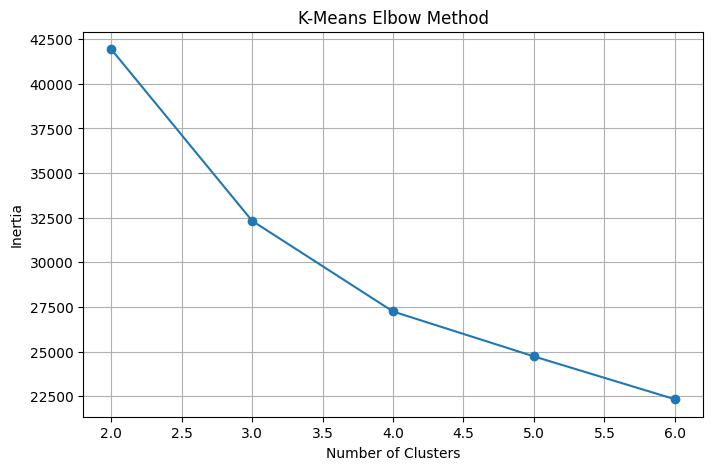

In [18]:
# ============================================================
# CELL 16: K-MEANS ELBOW METHOD
# ============================================================

inertia = []

k_values = range(2, 7)


for k in k_values:

    temp_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    temp_kmeans.fit(
        X_train_processed
    )

    inertia.append(
        temp_kmeans.inertia_
    )


plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title(
    "K-Means Elbow Method"
)

plt.grid(True)

plt.show()

In [19]:
# ============================================================
# CELL 17: SILHOUETTE SCORE
# ============================================================

for k in range(2, 7):

    temp_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = temp_kmeans.fit_predict(
        X_train_processed
    )

    score = silhouette_score(
        X_train_processed,
        labels
    )

    print(
        f"K = {k} | Silhouette Score = {score:.4f}"
    )

K = 2 | Silhouette Score = 0.3130
K = 3 | Silhouette Score = 0.3609
K = 4 | Silhouette Score = 0.2758
K = 5 | Silhouette Score = 0.2890
K = 6 | Silhouette Score = 0.2204


In [20]:
# ============================================================
# CELL 18: K-MEANS CLUSTERING
# ============================================================

K = 3

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)


train_clusters = kmeans.fit_predict(
    X_train_processed
)


test_clusters = kmeans.predict(
    X_test_processed
)


print("K-Means completed.")

print("\nTraining cluster distribution:")

print(
    pd.Series(
        train_clusters
    ).value_counts().sort_index()
)

K-Means completed.

Training cluster distribution:
0    2640
1     864
2     134
Name: count, dtype: int64


In [21]:
# ============================================================
# CELL 19: ADD CLUSTER FEATURE
# ============================================================

X_train_hybrid = np.column_stack([
    X_train_processed,
    train_clusters
])


X_test_hybrid = np.column_stack([
    X_test_processed,
    test_clusters
])


print(
    "Hybrid training shape:",
    X_train_hybrid.shape
)

print(
    "Hybrid testing shape:",
    X_test_hybrid.shape
)

Hybrid training shape: (3638, 36)
Hybrid testing shape: (910, 36)


In [22]:
# ============================================================
# CELL 20: RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1

)


rf.fit(
    X_train_hybrid,
    y_train
)


print(
    "Random Forest training completed!"
)

Random Forest training completed!


In [23]:
# ============================================================
# CELL 21: PREDICTIONS
# ============================================================

y_pred = rf.predict(
    X_test_hybrid
)


y_probability = rf.predict_proba(
    X_test_hybrid
)[:, 1]


print("Predictions completed.")

Predictions completed.


In [24]:
# ============================================================
# CELL 22: MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("========================================")
print("K-MEANS + RANDOM FOREST")
print("========================================")

print(
    "Accuracy  :",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision :",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall    :",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score  :",
    round(f1 * 100, 2),
    "%"
)

print(
    "ROC-AUC   :",
    round(roc_auc, 4)
)

K-MEANS + RANDOM FOREST
Accuracy  : 75.49 %
Precision : 69.14 %
Recall    : 57.06 %
F1 Score  : 62.52 %
ROC-AUC   : 0.7984


In [25]:
# ============================================================
# CELL 23: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Flood",
            "Severe Flood"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Flood       0.78      0.86      0.82       584
Severe Flood       0.69      0.57      0.63       326

    accuracy                           0.75       910
   macro avg       0.74      0.71      0.72       910
weighted avg       0.75      0.75      0.75       910



Confusion Matrix:
[[501  83]
 [140 186]]


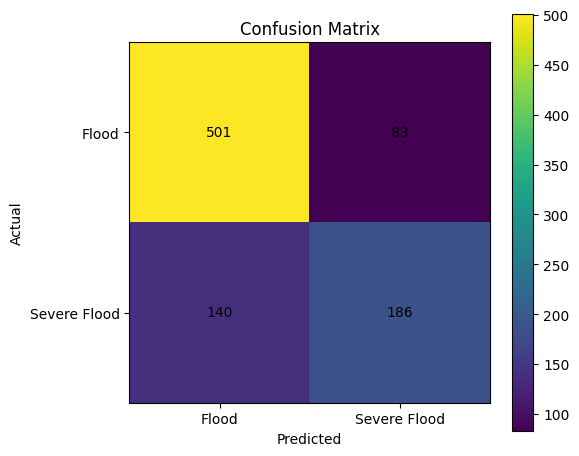

In [26]:
# ============================================================
# CELL 24: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")

print(cm)


plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Flood", "Severe Flood"]
)

plt.yticks(
    [0, 1],
    ["Flood", "Severe Flood"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# CELL 25: FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


feature_names = list(
    feature_names
)

feature_names.append(
    "KMeans_Cluster"
)


importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf.feature_importances_

})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


print(
    importance_df.head(20)
)

                                         Feature  Importance
0                                       num__T1d    0.139074
4                                      num__T10d    0.125726
3                                       num__T7d    0.123407
1                                       num__T3d    0.121440
2                                       num__T5d    0.119841
6                      num__Annual Precipitation    0.050400
9                          num__Catchment Relief    0.047637
8                             num__Drainage Area    0.039262
11                        num__Ruggedness Number    0.038582
5                   num__Annual Mean Temperature    0.035705
12                       num__Population Density    0.031425
10                         num__Drainage Density    0.031235
7                              num__Stream Order    0.011915
26                       cat__Soil type_Luvisols    0.009730
19             cat__Land cover_Mosaic vegetation    0.009216
17                      

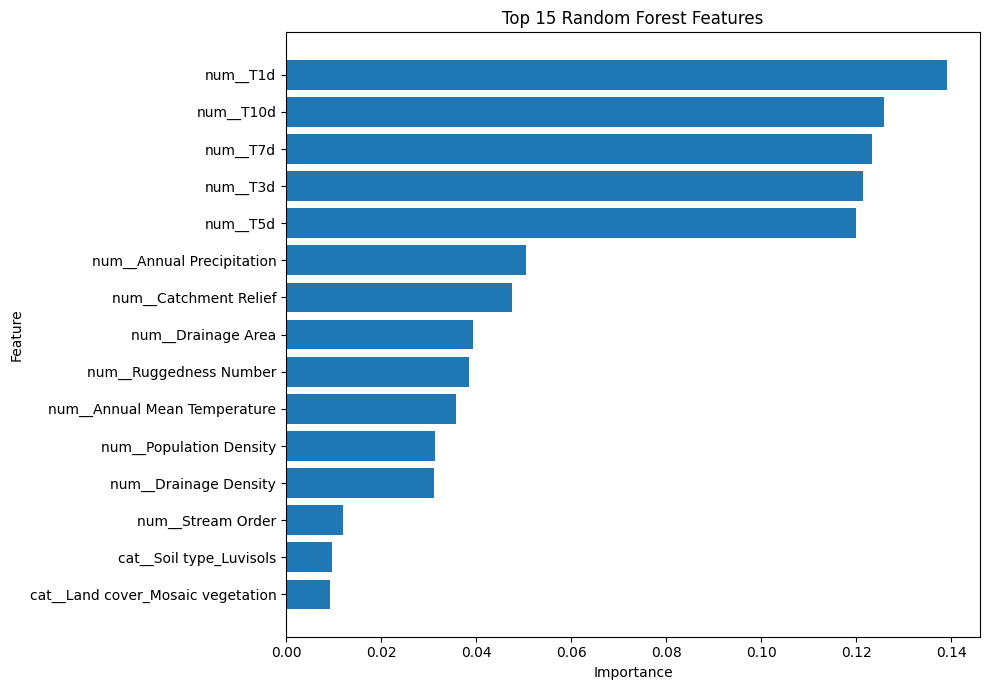

In [28]:
# ============================================================
# CELL 26: FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = (
    importance_df
    .head(15)
    .sort_values(
        by="Importance"
    )
)


plt.figure(figsize=(10, 7))


plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)


plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Random Forest Features"
)

plt.tight_layout()

plt.show()

In [29]:
# ============================================================
# CELL 27: CLUSTER ANALYSIS
# ============================================================

cluster_analysis = X_train.copy()

cluster_analysis["Cluster"] = train_clusters

cluster_analysis["Target"] = y_train.values


print(
    cluster_analysis
    .groupby("Cluster")
    .mean(numeric_only=True)
)

               T1d         T3d         T5d         T7d        T10d  \
Cluster                                                              
0        23.049142   55.556396   77.700969  100.135217  132.491210   
1        92.664994  220.981608  320.011498  410.770388  535.656623   
2        20.792470   53.815468   83.330501  111.984129  155.311022   

         Annual Mean Temperature  Annual Precipitation  Stream Order  \
Cluster                                                                
0                      25.113276           1291.846113      4.581061   
1                      25.132567           3453.384959      3.127315   
2                       9.549919           1676.541771      4.604478   

         Drainage Area  Catchment Relief  Drainage Density  Ruggedness Number  \
Cluster                                                                         
0         22243.850533       1093.176894          0.000160           0.174622   
1          2127.622875       1099.464120     

In [30]:
# ============================================================
# CELL 28: TEST ONE REAL EVENT
# ============================================================

sample = X_test.iloc[[0]].copy()

actual = y_test.iloc[0]


sample_processed = preprocessor.transform(
    sample
)


sample_cluster = kmeans.predict(
    sample_processed
)


sample_hybrid = np.column_stack([
    sample_processed,
    sample_cluster
])


prediction = rf.predict(
    sample_hybrid
)[0]


probability = rf.predict_proba(
    sample_hybrid
)[0][1]


print("========================================")
print("PREDICTION RESULT")
print("========================================")

print(
    "Actual:",
    "Severe Flood"
    if actual == 1
    else "Flood"
)

print(
    "Predicted:",
    "Severe Flood"
    if prediction == 1
    else "Flood"
)

print(
    "Severe Flood Probability:",
    round(
        probability * 100,
        2
    ),
    "%"
)

print(
    "K-Means Cluster:",
    sample_cluster[0]
)

print("========================================")

PREDICTION RESULT
Actual: Severe Flood
Predicted: Severe Flood
Severe Flood Probability: 80.67 %
K-Means Cluster: 0


In [31]:
# ============================================================
# CELL 29: PREDICTION FUNCTION
# ============================================================

def predict_flood_severity(
    T1d,
    T3d,
    T5d,
    T7d,
    T10d,
    annual_mean_temperature,
    annual_precipitation,
    stream_order,
    drainage_area,
    catchment_relief,
    drainage_density,
    ruggedness_number,
    population_density,
    climate_type,
    land_cover,
    soil_type,
    lithology_type
):

    input_data = pd.DataFrame([{

        "T1d": T1d,

        "T3d": T3d,

        "T5d": T5d,

        "T7d": T7d,

        "T10d": T10d,

        "Annual Mean Temperature":
            annual_mean_temperature,

        "Annual Precipitation":
            annual_precipitation,

        "Stream Order":
            stream_order,

        "Drainage Area":
            drainage_area,

        "Catchment Relief":
            catchment_relief,

        "Drainage Density":
            drainage_density,

        "Ruggedness Number":
            ruggedness_number,

        "Population Density":
            population_density,

        "KoppenGeiger Climate Type":
            climate_type,

        "Land cover":
            land_cover,

        "Soil type":
            soil_type,

        "lithology type":
            lithology_type
    }])


    processed = preprocessor.transform(
        input_data
    )


    cluster = kmeans.predict(
        processed
    )


    hybrid_input = np.column_stack([
        processed,
        cluster
    ])


    prediction = rf.predict(
        hybrid_input
    )[0]


    probability = rf.predict_proba(
        hybrid_input
    )[0][1]


    print("\n========================================")
    print("FLOOD SEVERITY PREDICTION")
    print("========================================")


    if prediction == 1:

        print(
            "Prediction: SEVERE FLOOD"
        )

    else:

        print(
            "Prediction: FLOOD"
        )


    print(
        "Severe Flood Probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )


    print(
        "K-Means Cluster:",
        cluster[0]
    )


    print("========================================")


    return (
        prediction,
        probability,
        cluster[0]
    )

In [32]:
# ============================================================
# CELL 30: EXAMPLE PREDICTION
# ============================================================

example_row = X_test.iloc[0]

predict_flood_severity(

    T1d=example_row["T1d"],

    T3d=example_row["T3d"],

    T5d=example_row["T5d"],

    T7d=example_row["T7d"],

    T10d=example_row["T10d"],

    annual_mean_temperature=
        example_row["Annual Mean Temperature"],

    annual_precipitation=
        example_row["Annual Precipitation"],

    stream_order=
        example_row["Stream Order"],

    drainage_area=
        example_row["Drainage Area"],

    catchment_relief=
        example_row["Catchment Relief"],

    drainage_density=
        example_row["Drainage Density"],

    ruggedness_number=
        example_row["Ruggedness Number"],

    population_density=
        example_row["Population Density"],

    climate_type=
        example_row["KoppenGeiger Climate Type"],

    land_cover=
        example_row["Land cover"],

    soil_type=
        example_row["Soil type"],

    lithology_type=
        example_row["lithology type"]
)


FLOOD SEVERITY PREDICTION
Prediction: SEVERE FLOOD
Severe Flood Probability: 80.67 %
K-Means Cluster: 0


(np.int64(1), np.float64(0.8066666666666666), np.int32(0))

In [ ]:
# ============================================================
# CELL 31: SAVE MODEL
# ============================================================

model_package = {

    "preprocessor": preprocessor,

    "kmeans": kmeans,

    "random_forest": rf,

    "features": all_features,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "target_mapping": {
        0: "Flood",
        1: "Severe Flood"
    }
}


joblib.dump(
    model_package,
    "D:\project\flood\Flood-Prediction-System-ML\models\INDOFLOODS_Hybrid_Model.joblib"
)


print(
    "Model saved successfully!"
)

print(
    "File: INDOFLOODS_Hybrid_Model.joblib"
)

Model saved successfully!
File: INDOFLOODS_Hybrid_Model.joblib


In [ ]:
# ============================================================
# SAVE MODEL METRICS
# ============================================================

metrics_text = f"""
INDOFLOODS K-Means + Random Forest Model

Target:
Flood vs Severe Flood

Accuracy  : {accuracy * 100:.2f}%
Precision : {precision * 100:.2f}%
Recall    : {recall * 100:.2f}%
F1 Score  : {f1 * 100:.2f}%
ROC-AUC   : {roc_auc:.4f}

Dataset Size:
Total samples: {len(master)}

Train samples: {len(X_train)}
Test samples: {len(X_test)}
"""

with open(
    "D:\project\flood\Flood-Prediction-System-ML\results\metrics\model_metrics.txt",
    "w"
) as file:

    file.write(metrics_text)

print("Metrics saved.")